DEN CODE MUSS ICH NOCH ANPASSEN
Create ontologies, starting with the generalized questions per cluster and then further refine the ontologies by 1) including the detailled CQs, and 2) including the sources



1) Create Cluster using the Top Down Approach. For refining only CQs are used

In [2]:
import os
import re
import json
import time
from mistralai import Mistral

In [3]:
api_key = "ujI60UR6Fe5jel48SAtfnMiN5Skxfwhq"
modelAI = "open-mistral-nemo"
client = Mistral(api_key=api_key)

In [ ]:
# Load generalized CQs 
with open("competency_questions_output/generalized_questions_new.json", "r", encoding="utf-8") as f:
    generalized_questions = json.load(f)

# Cluster -1 entfernen, falls vorhanden
generalized_questions = {
    k: v for k, v in generalized_questions.items() if k != "Cluster -1"
}


In [6]:
#Ontology prompt for generalized questions
gcq_ontology_prompt = """
You are an expert legal ontology expert.

You will receive a **generalized legal competency question (GCQ)**. 
Your task is to create a legal ontology that captures the core legal structure needed to answer this question.
The ontology must therefore be derived and shaped specifically to support answering **these questions**

Your output must consist of the following three components:

1. **Classes**: Key legal entities or concepts (e.g., Vertrag, Arbeitnehmer, Kündigung, Urteil, Entscheidungsgründe, Anspruch, Person, Tatbestand, Einwendung, Rubrum, Tenor)
2. **Properties**: Verbs or phrases representing relationships or attributes , so legally meaningful relationships or predicates (e.g., beinhaltet, basiert auf, verhindert, erörtern, hatAnspruchAuf, basiertAuf, führtZu)
3. **Relationships**: Triples (Subject)-(Predicate)-(Object), linking two classes via a property

Requierements:
- The ontology must be **generalized** and not specific to any single case or text.
- The ontology must be **comprehensive** and cover all relevant legal concepts needed to answer the GCQ.
- The ontology must be expressed in clear legal language in German.
- Only extract concepts if they have relationships.
- Only use legally meaningful and abstract concepts.
- Avoid overly specific or case-based terms.
- All relationships must connect two classes.
- All terms should be legally relevant and appropriately capitalized.
- The GCQs are the purpose of the ontology! It must contain exactly the legal knowledge needed to enable a meaningful and structured answer to the questions!

Output format as example:
{
  "classes": ["Urteil", "Anspruch", "Tatbestand"],
  "properties": ["beinhaltet", "basiert auf"],
  "relationships": [
    ["Urteil", "beinhaltet", "Tatbestand"],
    ["Anspruch", "basiert auf", "Tatbestand"]
  ]
}

If nothing relevant is found, return empty lists for each field.

## Few-Shot Examples 
"Sentence: 'Ein Arbeitnehmer hat eine Sozialversicherungsnummer'"
"Classes: [Arbeitnehmner, Sozialversicherungsnummer]"
"Properties: [hatIdentifikation]"
"Relationship: [(Arbeitnehmer)-(hatIdentifikation)-(Sozialversicherungsnummer)]"

"Sentence: 'Arbeitnehmer haben nach Gesetz einen geregelten Mindestanspruch auf 24 Tage Urlaub im Jahr'"
"Classes: [Arbeitnehmer, Urlaub]"
"Properties: [hatMindestAnspruchAuf]"
"Relationship: [(Arbeitnehmer)-(hatMindestAnspruchAuf)-(Urlaub)]"

## Modelling Guidelines
- **Concept Identification**:
  - Identify nouns and noun phrases as potential **Classes**.
  - Identify verbs and verb phrases as potential **Properties**.
  - Identify prepositions that establish relationships between nouns.

- **Classes**:
  - Represent concepts in the domain, not the words that denote these concepts.
  - Avoid creating classes for synonyms; use a single class for concepts with the same meaning.

- **Properties**:
  - Represent significant relationships or attributes between classes.
  - Should be meaningful and represent a significant connection.

- **Relationships**:
  - Establish connections between classes using properties.
  - Ensure relationships are meaningful within the domain context.

- **General Principles**:
  - There is no single correct way to model a domain; the best solution depends on the application.
  - ontology development is an iterative process; refine as needed.
  - Avoid cycles in the class hierarchy.
  - Siblings in the hierarchy should be at the same level of generality.

## Naming Conventions
**General**:
- Do not add strings like 'class', 'domain', 'range', 'property', or 'slot' to names.
- Use consistent naming throughout the ontology.

**Classes**:
- Names are always capitalized.
- Use nouns or compound nouns (e.g., Vertrag, Arbeit, Arbeitsvertrag).
- Use singular over plural (e.g., Arbeitsvertrag instead of Arbeitsverträge).
- Avoid abbreviations (e.g., Arbeitgeber instead of AG).

**Properties**:
- Names start with a lower-case letter.
- Use verbs or verb phrases.
- Can contain nouns in CamelCase starting with a verb (e.g., hatAnspruchAuf).
- Do not include spaces, commas, asterisks, or special characters.

## Finally
- Ensure that you include empty lists for classes, properties, or relationships if none are found.
- Make sure all extracted components, i.e. classes, properties, and relationships as well as all descriptions are in German and translate where necessary.
- Include a class only if at least one relationship is found for a class. Verify this requirement.
- Check carefully for each class without any relationship, based on the name and the description of the class, if it can be merged with another class or if it is actually a relationship between one class and another.
- All ontology components must be in German language!
- Terms like 'range' or 'domain' are never allowed!
- Remember, the puprose of the ontology is to enable structured, legally grounded answers to the legal questions provided in this cluster. The ontology must therefore be derived and shaped specifically to support answering these questions, based on the legal reasoning and terminology found in the accompanying source texts.
"""


In [7]:
# Ontologies for generalized questions 
gcq_ontologies = {}

for cluster_id, gcq in generalized_questions.items():
    try:
        response = client.chat.complete(
            model=modelAI,
            messages=[
                {"role": "system", "content": gcq_ontology_prompt},
                {"role": "user", "content": gcq.strip()}
            ],
            temperature=0.5
        )
        content = response.choices[0].message.content.strip()

        try:
            ontology = json.loads(content)
            rels = ontology.get("relationships", [])

            # only use classes that are actually used in relationships 
            valid_classes = set()
            for rel in rels:
                if isinstance(rel, list) and len(rel) == 3:
                    valid_classes.add(rel[0])
                    valid_classes.add(rel[2])

            ontology["classes"] = [cls for cls in ontology.get("classes", []) if cls in valid_classes]
            gcq_ontologies[cluster_id] = {
                "gcq": gcq,
                "ontology": ontology
            }
            print(f"✅ Ontology created for {cluster_id}")

        except json.JSONDecodeError:
            print(f"❌ Invalid JSON in response for {cluster_id}")

    except Exception as e:
        print(f"❌ Error in cluster {cluster_id}: {e}")
    time.sleep(3)

# Safe results
os.makedirs("ontology_output", exist_ok=True)
with open("ontology_output/gcq_ontology_topdown.json", "w", encoding="utf-8") as f:
    json.dump(gcq_ontologies, f, ensure_ascii=False, indent=2)

print("\n✅ Ontology generation from generalized questions completed.")


✅ Ontology created for Cluster 0
✅ Ontology created for Cluster 1
✅ Ontology created for Cluster 2
✅ Ontology created for Cluster 3
✅ Ontology created for Cluster 4
✅ Ontology created for Cluster 5
✅ Ontology created for Cluster 6
✅ Ontology created for Cluster 7
✅ Ontology created for Cluster 8
✅ Ontology created for Cluster 9
✅ Ontology created for Cluster 10
✅ Ontology created for Cluster 11
✅ Ontology created for Cluster 12
✅ Ontology created for Cluster 13
✅ Ontology created for Cluster 14
✅ Ontology created for Cluster 15
✅ Ontology created for Cluster 16
✅ Ontology created for Cluster 17
✅ Ontology created for Cluster 18
✅ Ontology created for Cluster 19
✅ Ontology created for Cluster 20
✅ Ontology created for Cluster 21
✅ Ontology created for Cluster 22
✅ Ontology created for Cluster 23
✅ Ontology created for Cluster 24
✅ Ontology created for Cluster 25
✅ Ontology created for Cluster 26
✅ Ontology created for Cluster 27
✅ Ontology created for Cluster 28
✅ Ontology created for C

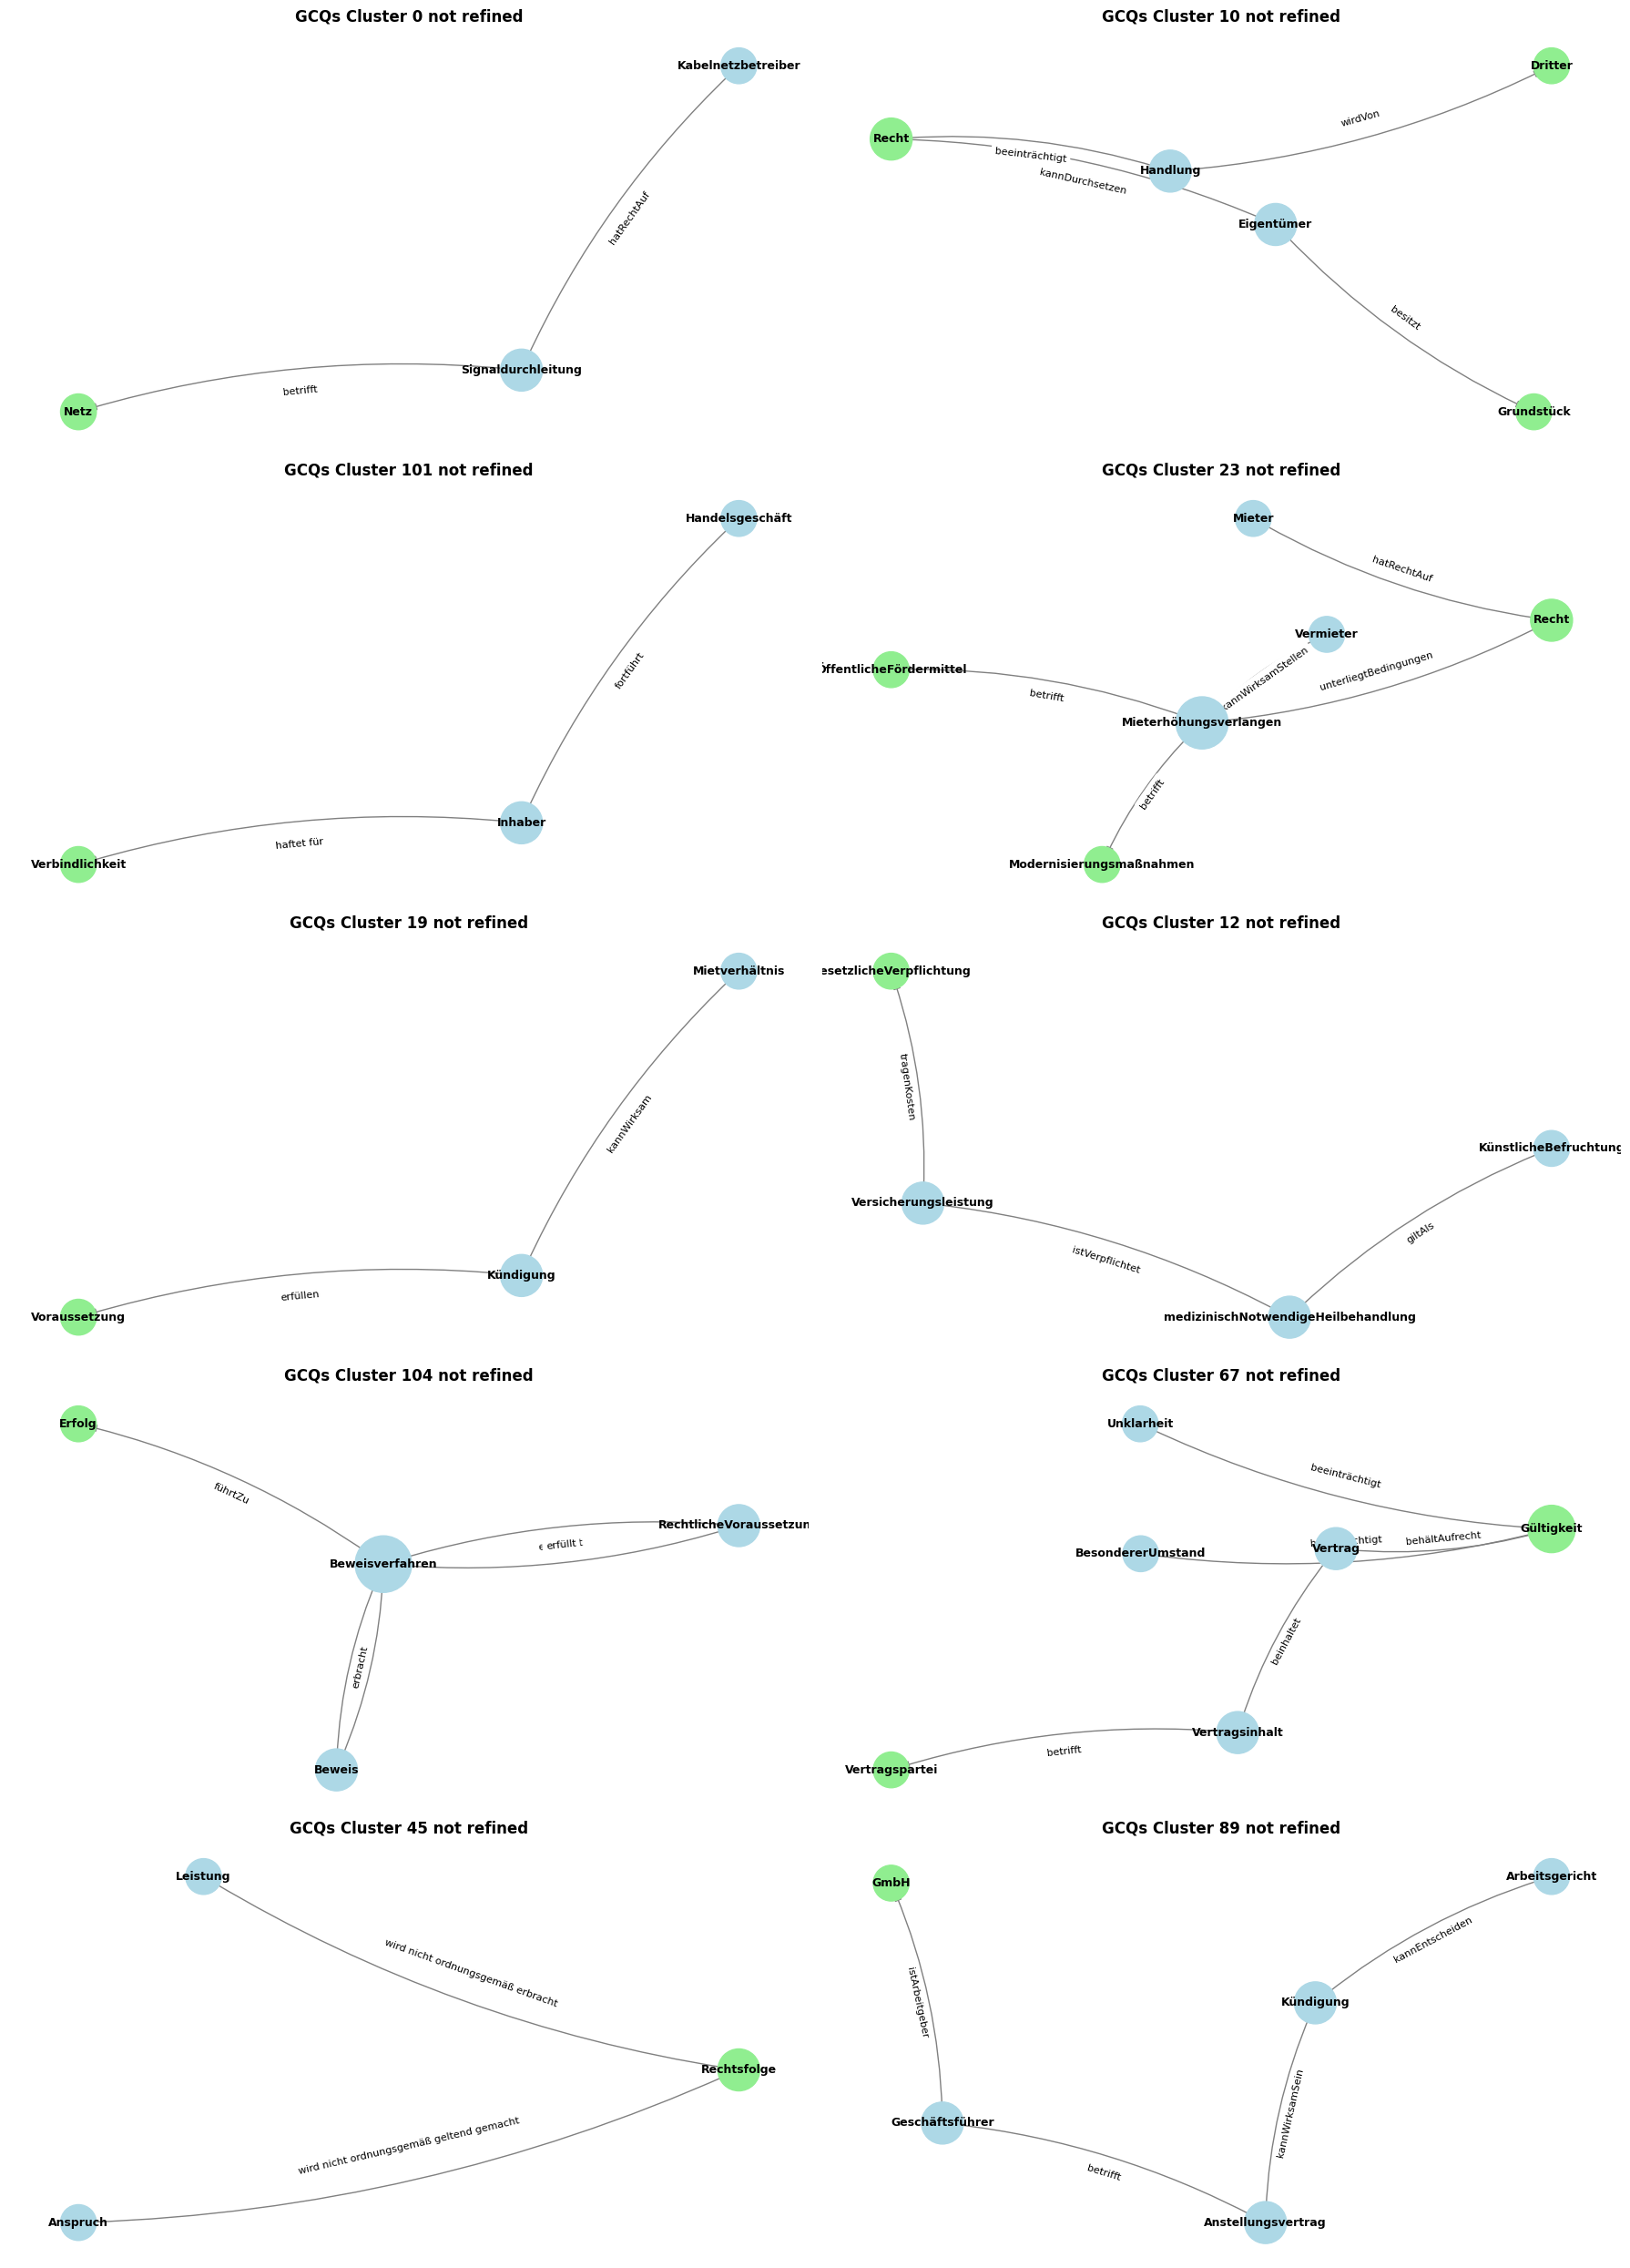

In [8]:
#Visualize GCQs ontologies 

import json
import matplotlib.pyplot as plt
import networkx as nx

# === Load Ontologies ===
with open("ontology_output/gcq_ontology_topdown.json", "r", encoding="utf-8") as f:
    ontology_data = json.load(f)

# === Specify 10 Desired Clusters ===
selected_clusters = [
    "Cluster 0", "Cluster 10", "Cluster 101",
    "Cluster 23", "Cluster 19", "Cluster 12",
    "Cluster 104", "Cluster 67", "Cluster 45", "Cluster 89"
]

# === Plot Setup ===
num_clusters = len(selected_clusters)
cols = 2
rows = (num_clusters + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, cluster_id in enumerate(selected_clusters):
    data = ontology_data.get(cluster_id)
    ax = axes[i]

    if not data:
        print(f"⚠️ Cluster {cluster_id} not found in data.")
        ax.set_title(f"{cluster_id}: Not found")
        ax.axis("off")
        continue

    ontology = data.get("ontology", {})
    relationships = ontology.get("relationships", [])

    if not relationships:
        ax.set_title(f"{cluster_id}: No relationships")
        ax.axis("off")
        continue

    G = nx.DiGraph()
    for rel in relationships:
        if isinstance(rel, list) and len(rel) == 3:
            subj, pred, obj = rel
            G.add_edge(subj, obj, label=pred)

    pos = nx.spring_layout(G, k=1.3, seed=42)
    degrees = dict(G.degree())

    node_colors = [
        "lightblue" if node in [r[0] for r in relationships] else "lightgreen"
        for node in G.nodes()
    ]
    node_sizes = [500 + degrees[n] * 300 for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), font_size=8, ax=ax)

    # Show only cluster ID
    ax.set_title(f"GCQs {cluster_id} not refined", fontsize=12, fontweight="bold")
    ax.axis("off")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Refine the ontologies using the CQs 

In [ ]:
# Load generalized CQs ===
with open("competency_questions_output/generalized_questions_new.json", "r", encoding="utf-8") as f:
    generalized_questions = json.load(f)

generalized_questions = {k: v for k, v in generalized_questions.items() if k != "Cluster -1"}

# === Load previous GCQ-based ontologies ===
with open("ontology_output/gcq_ontology_topdown.json", "r", encoding="utf-8") as f:
    gcq_ontologies = json.load(f)

# === Load detailed CQs with noise handled ===
with open("clustered_questions/clustered_CQs_with_promoted_and_reviewed_noise_new.json", "r", encoding="utf-8") as f:
    detailed_clusters = json.load(f)

In [10]:
# System prompt for ontology refinement ===
refinement_prompt = """
You are a legal ontology expert.
You will receive:
- an existing legal ontology based on a **generalized legal competency question (GCQ)**
- multiple **detailed legal competency questions (CQs)** 

Goals:
- Refine and expand the ontology to include essential legal concepts, relationships, or terms present in the detailed questions

The ontology must:
- Refine and expand the abstraction level and structure of the GCQ-based ontology but keep in mind the legal concepts and relationships needed to answer the GCQ.
- Be expressed in clear, high-level **legal German**
- Include **only legally meaningful and general concepts** that are relevant for answering the GCQ
- Expand the ontology to include all relevant legal concepts, relationships, or terms present in the detailed questions and their sources.

Output format (strict): 
You must return ONLY a plain JSON object with exactöy this structure and keys:
```json
{
  "classes": [...],
  "properties": [...],
  "relationships": [[Subject, Predicate, Object], ...]
}
- Do not include any other text, explanations, or comments.
- Do not include synonyms or lexical variants (e.g., Schadensersatzpflicht, Schadensersatzverpflichtung, Schadensersatzrecht). Choose the most abstract and widely used term only
- Only keep concepts with at least one relationship.
- Do not return explanations, input data, headings, markdown, or code fences — only the pure JSON object, and nothing else.
- If nothing applies, return: {"classes": [], "properties": [], "relationships": []}
- Return only this exact structure as plain JSON: {"classes": [...], "properties": [...], "relationships": [[A, B, C], ...]}
"""

In [11]:
# Build refined ontologies based on GCQ and detailed CQs
refined_ontologies = {}

for cluster_id, base in gcq_ontologies.items():
    if cluster_id == "Cluster -1" or cluster_id not in detailed_clusters:
        continue

    base_ontology = base.get("ontology", {})
    gcq = base.get("gcq") or base.get("generalized_question", "")
    detailed_entries = detailed_clusters[cluster_id]

    detailed_input = "\n\n".join(
        f"**Frage:** {e['cq']}\n**Quelle:** {e['quelle']}"
        for e in detailed_entries if e.get("cq") and e.get("quelle")
    )

    user_input = {
        "generalized_question": gcq,
        "existing_ontology": base_ontology,
        "detailed_questions": detailed_input
    }

    try:
        response = client.chat.complete(
            model=modelAI,
            messages=[
                {"role": "system", "content": refinement_prompt},
                {"role": "user", "content": json.dumps(user_input, ensure_ascii=False)}
            ],
            temperature=0.4
        )
        content = response.choices[0].message.content.strip()
        match = re.search(r"\{.*\}", content, re.DOTALL)
        if not match:
            print(f"❌ JSON error for {cluster_id}")
            print("Raw content:\n", content[:1000])
            continue

        try:
            parsed = json.loads(match.group(0))
            
            MAX_CLASSES = 30
            MAX_PROPERTIES = 20

            parsed["classes"] = parsed["classes"][:MAX_CLASSES]
            parsed["properties"] = parsed["properties"][:MAX_PROPERTIES]

            # Remove excessively long class or property names
            parsed["classes"] = [c for c in parsed.get("classes", []) if len(c) < 50]
            parsed["properties"] = list({p for p in parsed.get("properties", []) if len(p) < 40})

            rels = parsed.get("relationships", [])
            used_classes = {r[0] for r in rels if len(r) == 3} | {r[2] for r in rels if len(r) == 3}
            parsed["classes"] = [cls for cls in parsed["classes"] if cls in used_classes]

            refined_ontologies[cluster_id] = {
                "generalized_question": gcq,
                "refined_ontology": parsed
            }
            print(f"✅ Refined ontology for {cluster_id}")
        except json.JSONDecodeError as e:
            print(f"❌ JSON decoding error for {cluster_id}: {e}")
            print("Raw content:\n", match.group(0)[:1000])
    except Exception as e:
        print(f"❌ API error for {cluster_id}: {e}")
    time.sleep(2)

# === Save Refined ===
os.makedirs("ontology_output", exist_ok=True)
with open("ontology_output/gcq_ontology_topdown_refined.json", "w", encoding="utf-8") as f:
    json.dump(refined_ontologies, f, indent=2, ensure_ascii=False)

print("\n✅ Ontology refinement completed and saved.")


✅ Refined ontology for Cluster 0
✅ Refined ontology for Cluster 1
✅ Refined ontology for Cluster 2
✅ Refined ontology for Cluster 3
✅ Refined ontology for Cluster 4
❌ JSON error for Cluster 5
Raw content:
 Based on the provided generalized legal competency question (GCQ) and the existing ontology, I have refined and expanded the ontology to include essential legal concepts, relationships, or terms present in the detailed questions. The refined ontology is expressed in clear, high-level legal German and includes only legally meaningful and general concepts relevant for answering the GCQ. Here is the expanded ontology:

```json
{
  "classes": [
    "Geräuschemission",
    "Schallschutzrecht",
    "Zumutbarkeit",
    "Faktor",
    "Immissionsschutzrecht",
    "Lärmschutzverordnung",
    "Umweltbelastung",
    "Schutzgut",
    "Schutzinteresse",
    "Schutzbereich",
    "Schutzpflicht",
    "Schutzrecht",
    "Schutzverpflichtung",
    "Schutzverletzung",
    "Schutzverletzungstatbestand",

KeyboardInterrupt: 

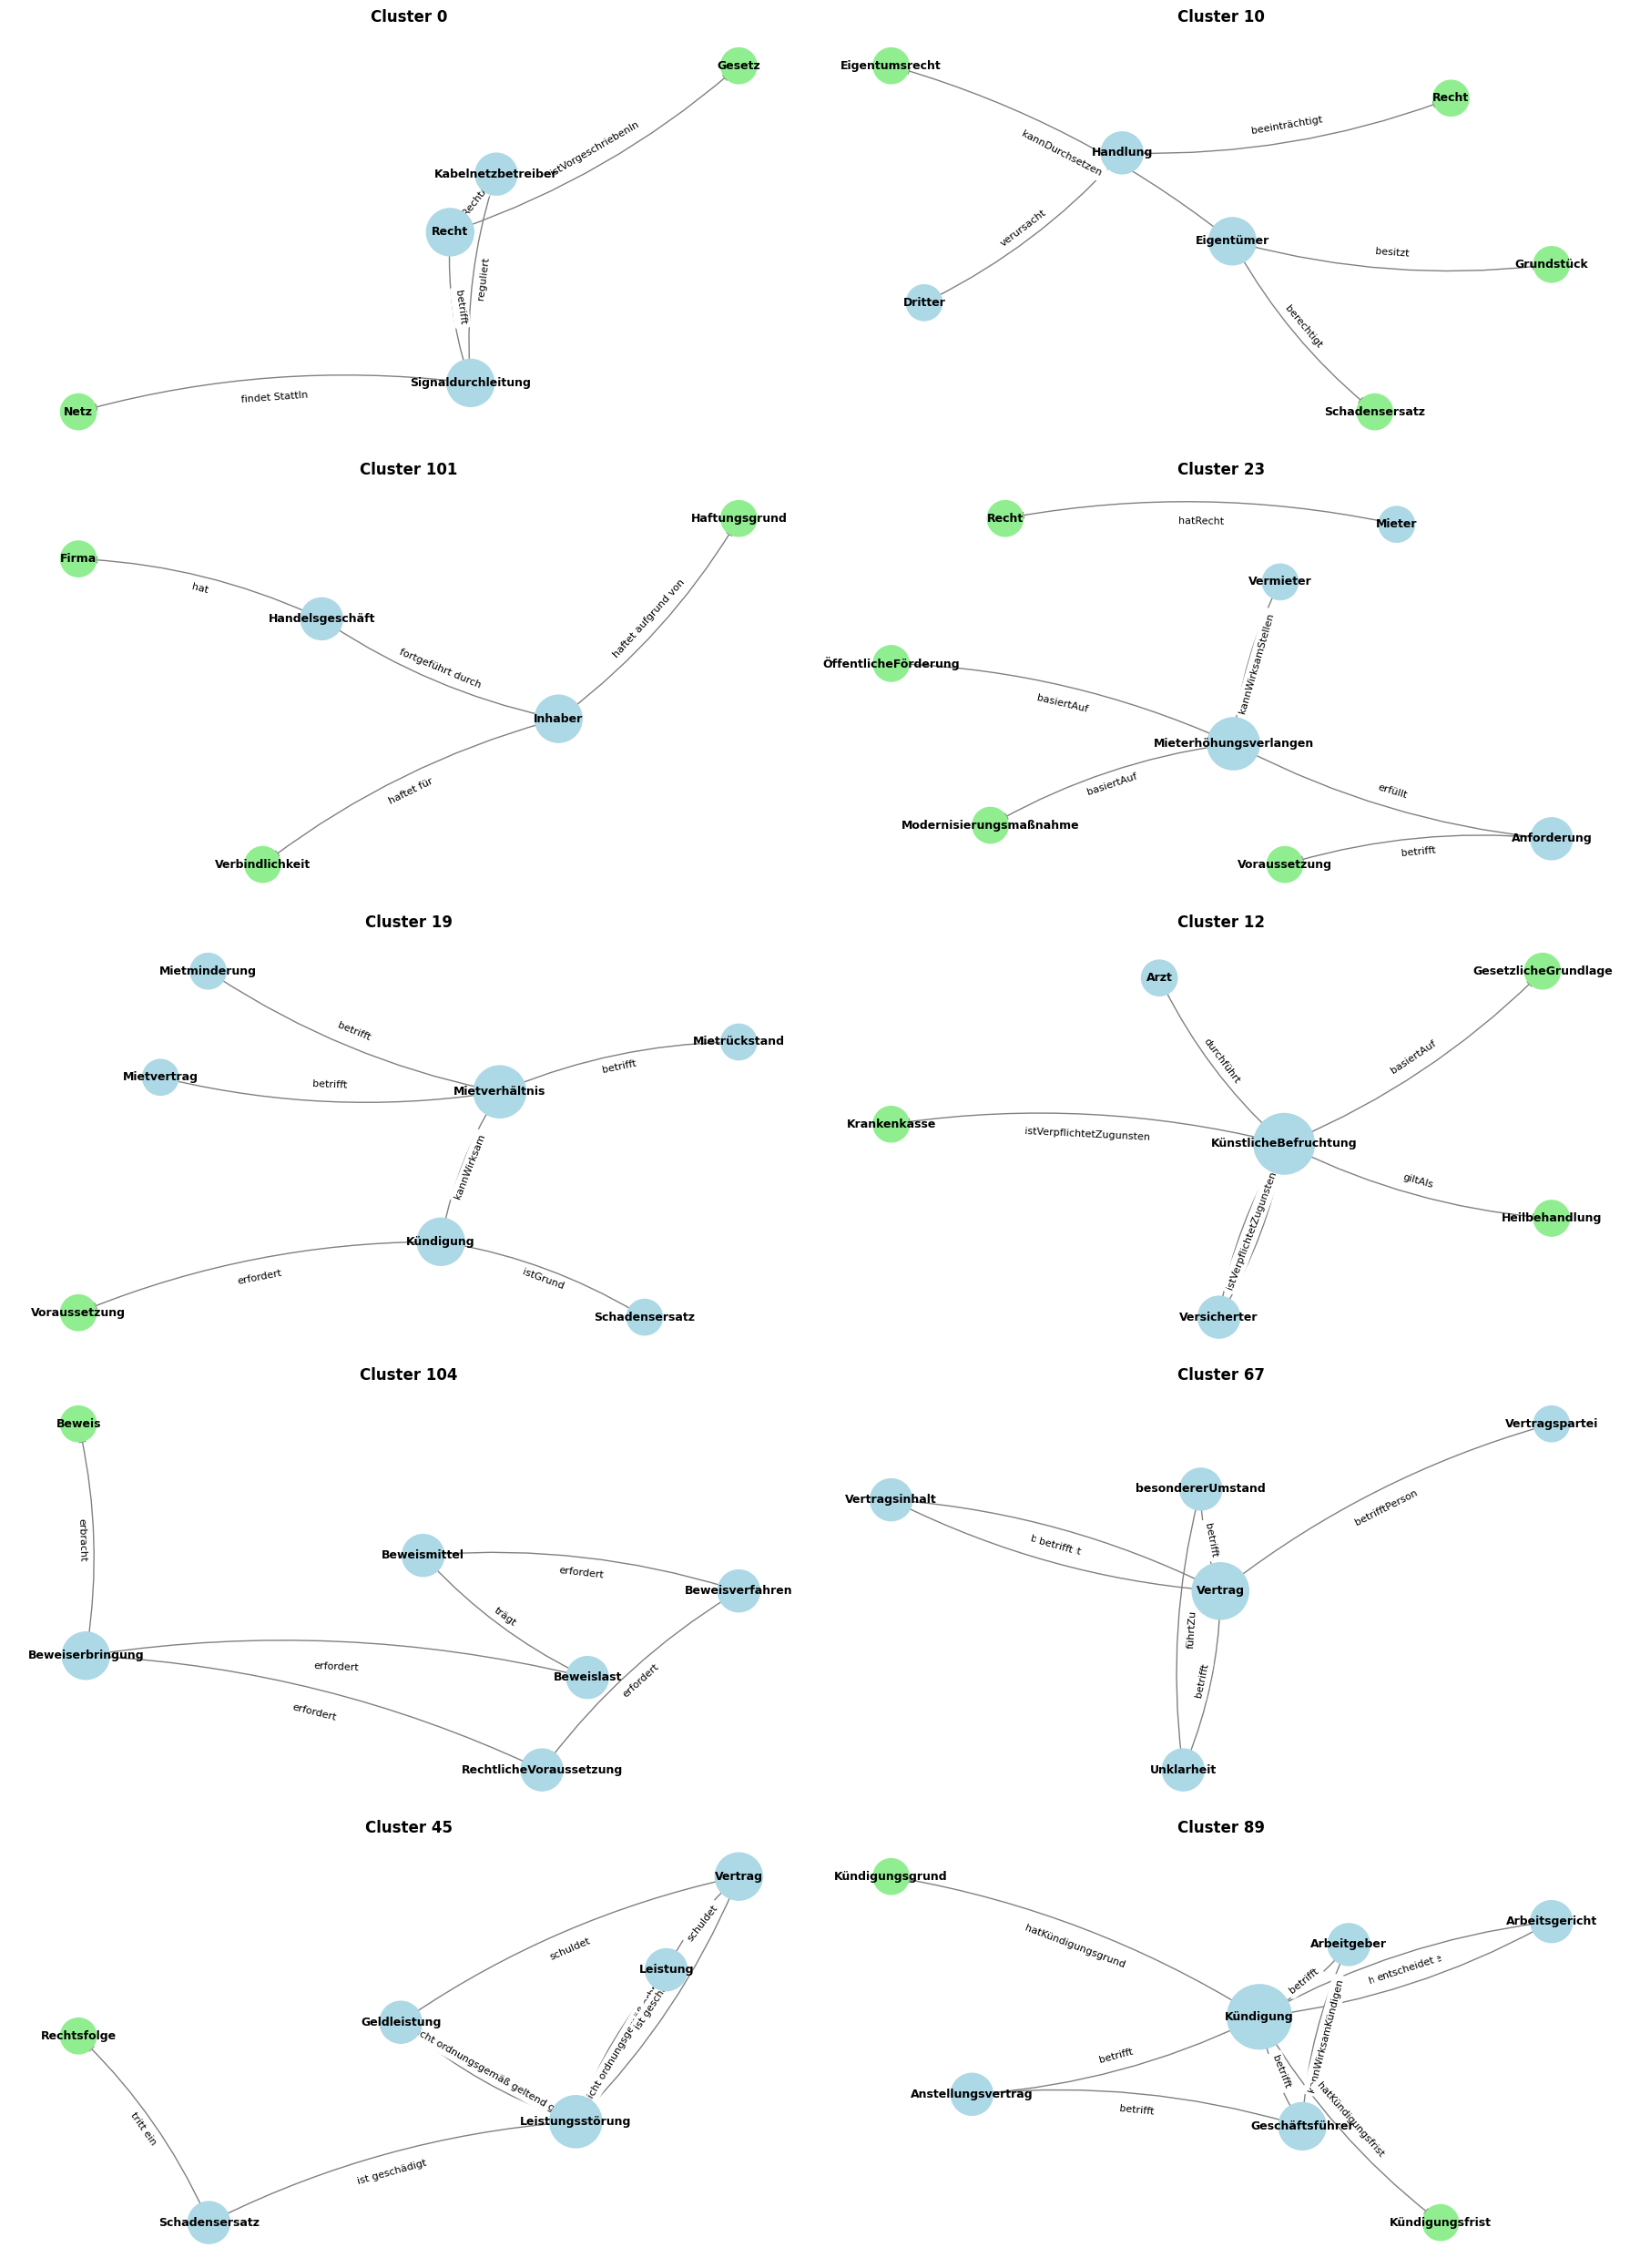

In [ ]:
#Visualize the refined generated ontologies with CQs
import json
import matplotlib.pyplot as plt
import networkx as nx

# === Load Refined Ontologies ===
with open("ontology_output/gcq_ontology_topdown_refined.json", "r", encoding="utf-8") as f:
    ontology_data = json.load(f)

# === Specify 10 Desired Clusters ===
selected_clusters = [
    "Cluster 0", "Cluster 10", "Cluster 101",
    "Cluster 23", "Cluster 19", "Cluster 12",
    "Cluster 104", "Cluster 67", "Cluster 45", "Cluster 89"
]

# === Plot Setup ===
num_clusters = len(selected_clusters)
cols = 2
rows = (num_clusters + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, cluster_id in enumerate(selected_clusters):
    data = ontology_data.get(cluster_id)
    ax = axes[i]

    if not data:
        print(f"⚠️ Cluster {cluster_id} not found in data.")
        ax.set_title(f"{cluster_id}: Not found")
        ax.axis("off")
        continue

    ontology = data.get("refined_ontology", {})
    relationships = ontology.get("relationships", [])

    if not relationships:
        ax.set_title(f"{cluster_id}: No relationships")
        ax.axis("off")
        continue

    G = nx.DiGraph()
    for rel in relationships:
        if isinstance(rel, (list, tuple)) and len(rel) == 3:
            subj, pred, obj = rel
            G.add_edge(subj, obj, label=pred)
        else:
            # Optionally, print or log skipped relationships
            # print(f"Skipped relationship (not a triple): {rel}")
            continue

    pos = nx.spring_layout(G, k=1.3, seed=42)
    degrees = dict(G.degree())

    node_colors = ["lightblue" if node in [r[0] for r in relationships] else "lightgreen" for node in G.nodes()]
    node_sizes = [500 + degrees[n] * 300 for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), font_size=8, ax=ax)

    ax.set_title(f"Refined {cluster_id} with CQs", fontsize=12, fontweight="bold")
    ax.axis("off")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


2) Refine the Ontologies built on GCQs using CQs and their respective sources

In [ ]:
# === Load generalized CQs ===
with open("competency_questions_output/generalized_questions_new.json", "r", encoding="utf-8") as f:
    generalized_source_questions = json.load(f)
# === Clean Generalized Questions ===
generalized_source_questions = {
    k: v for k, v in generalized_source_questions.items() if k != "Cluster -1"
}

# === Load previous GCQ-based ontologies ===
with open("ontology_output/gcq_ontology_topdown.json", "r", encoding="utf-8") as f:
    gcq_source_ontologies = json.load(f)

# === Load detailed CQs with noise handled ===
with open("clustered_questions/clustered_CQs_with_sources.json", "r", encoding="utf-8") as f:
    detailed_source_clusters = json.load(f)
    



In [ ]:
# System prompt for ontology refinement ===
refinement_prompt = """
You are a legal ontology expert.
You will receive:
- an existing legal ontology based on a **generalized legal competency question (GCQ)**
- multiple **detailed legal competency questions (CQs)** with their sources - so detailed questions and their sources

Goals:
- Expand or adjust the ontology to include essential legal concepts, relationships, or terms present in the detailed questions and their sources. 
- Explicitly include the sources in the ontology to get a more detailed and concrete answer to the GCQ. Create a detailed cluster. 
- Adjust the abstraction level of the GCQ-based ontology as needed
- Use the sources to refine the ontology and include relevant legal concepts, relationships, or terms that are present in the detailed questions and their sources.


The ontology must:
- Refine the abstraction level and structure of the GCQ-based ontology
- Be expressed in clear, high-level **legal German**
- Include **only legally meaningful and general concepts** that are relevant for answering the GCQ

Output format (strict): 
Return **only** a JSON object with this exact structure:

{
  "classes": [...],
  "properties": [...],
  "relationships": [[Subject, Predicate, Object], ...]
}

If nothing applies, return:

{
  "classes": [],
  "properties": [],
  "relationships": []
}
- Do not include any other text, explanations, or comments.
- Do not include synonyms or lexical variants (e.g., Schadensersatzpflicht, Schadensersatzverpflichtung, Schadensersatzrecht). Choose the most abstract and widely used term only
- Only keep concepts with at least one relationship.
- Do not return explanations, input data, headings, markdown, or code fences — only the pure JSON object, and nothing else.
- If nothing applies, return: {"classes": [], "properties": [], "relationships": []}
- Return only this exact structure as plain JSON: {"classes": [...], "properties": [...], "relationships": [[A, B, C], ...]}
"""

In [55]:
# Build refined ontologies based on GCQ and detailed CQs
refined_source_ontologies = {}

for cluster_id, base in gcq_source_ontologies.items():
    if cluster_id == "Cluster -1" or cluster_id not in detailed_source_clusters:
        continue

    base_ontology = base.get("ontology", {})
    gcq = base.get("gcq") or base.get("generalized_question", "")
    detailed_entries = detailed_source_clusters[cluster_id]

    detailed_input = "\n\n".join(
        f"**Frage:** {e['cq']}\n**Quelle:** {e['quelle']}"
        for e in detailed_entries if e.get("cq") and e.get("quelle")
    )

    user_input = {
        "generalized_question": gcq,
        "existing_ontology": base_ontology,
        "detailed_questions_and_sources": detailed_input
    }

    try:
        response = client.chat.complete(
            model=modelAI,
            messages=[
                {"role": "system", "content": refinement_prompt},
                {"role": "user", "content": json.dumps(user_input, ensure_ascii=False)}
            ],
            temperature=0.4
        )
        content = response.choices[0].message.content.strip()
        match = re.search(r"\{.*\}", content, re.DOTALL)

        if not match:
            print(f"❌ JSON structure error for {cluster_id}")
            with open(f"ontology_output/debug_cluster_{cluster_id}.txt", "w", encoding="utf-8") as f:
                f.write(content)
            continue

        try:
            parsed = json.loads(match.group(0))

            # Clean and deduplicate entries
            parsed["classes"] = list(set([c for c in parsed.get("classes", []) if len(c) < 50]))
            parsed["properties"] = list(set([p for p in parsed.get("properties", []) if len(p) < 40]))

            # De-duplicate relationships
            seen_rels = set()
            cleaned_rels = []
            for rel in parsed.get("relationships", []):
                if isinstance(rel, list) and len(rel) == 3:
                    key = tuple(rel)
                    if key not in seen_rels:
                        seen_rels.add(key)
                        cleaned_rels.append(rel)
            parsed["relationships"] = cleaned_rels

            # Filter unused classes
            used_classes = {r[0] for r in parsed["relationships"]} | {r[2] for r in parsed["relationships"]}
            parsed["classes"] = [cls for cls in parsed["classes"] if cls in used_classes]

            refined_source_ontologies[cluster_id] = {
                "generalized_question": gcq,
                "refined_ontology": parsed
            }

            print(f"✅ Refined combined ontology for {cluster_id}")

        except json.JSONDecodeError as e:
            print(f"❌ JSON decoding error for {cluster_id}: {e}")
            with open(f"ontology_output/debug_cluster_{cluster_id}.txt", "w", encoding="utf-8") as f:
                f.write(match.group(0))

    except Exception as e:
        print(f"❌ API error for {cluster_id}: {e}")

    time.sleep(3)

# === Save Refined Ontologies ===
os.makedirs("ontology_output", exist_ok=True)
with open("ontology_output/gcq_ontology_topdown_refined_source.json", "w", encoding="utf-8") as f:
    json.dump(refined_source_ontologies, f, indent=2, ensure_ascii=False)

print("\n✅ Ontology refinement completed and saved.")

✅ Refined combined ontology for Cluster 0
✅ Refined combined ontology for Cluster 1
✅ Refined combined ontology for Cluster 2
✅ Refined combined ontology for Cluster 3
✅ Refined combined ontology for Cluster 4
✅ Refined combined ontology for Cluster 5
✅ Refined combined ontology for Cluster 6
✅ Refined combined ontology for Cluster 7
✅ Refined combined ontology for Cluster 8
✅ Refined combined ontology for Cluster 9
✅ Refined combined ontology for Cluster 10
✅ Refined combined ontology for Cluster 11
✅ Refined combined ontology for Cluster 12
✅ Refined combined ontology for Cluster 13
✅ Refined combined ontology for Cluster 14
✅ Refined combined ontology for Cluster 15
✅ Refined combined ontology for Cluster 16
✅ Refined combined ontology for Cluster 17
✅ Refined combined ontology for Cluster 18
✅ Refined combined ontology for Cluster 19
✅ Refined combined ontology for Cluster 20
✅ Refined combined ontology for Cluster 21
✅ Refined combined ontology for Cluster 22
✅ Refined combined on

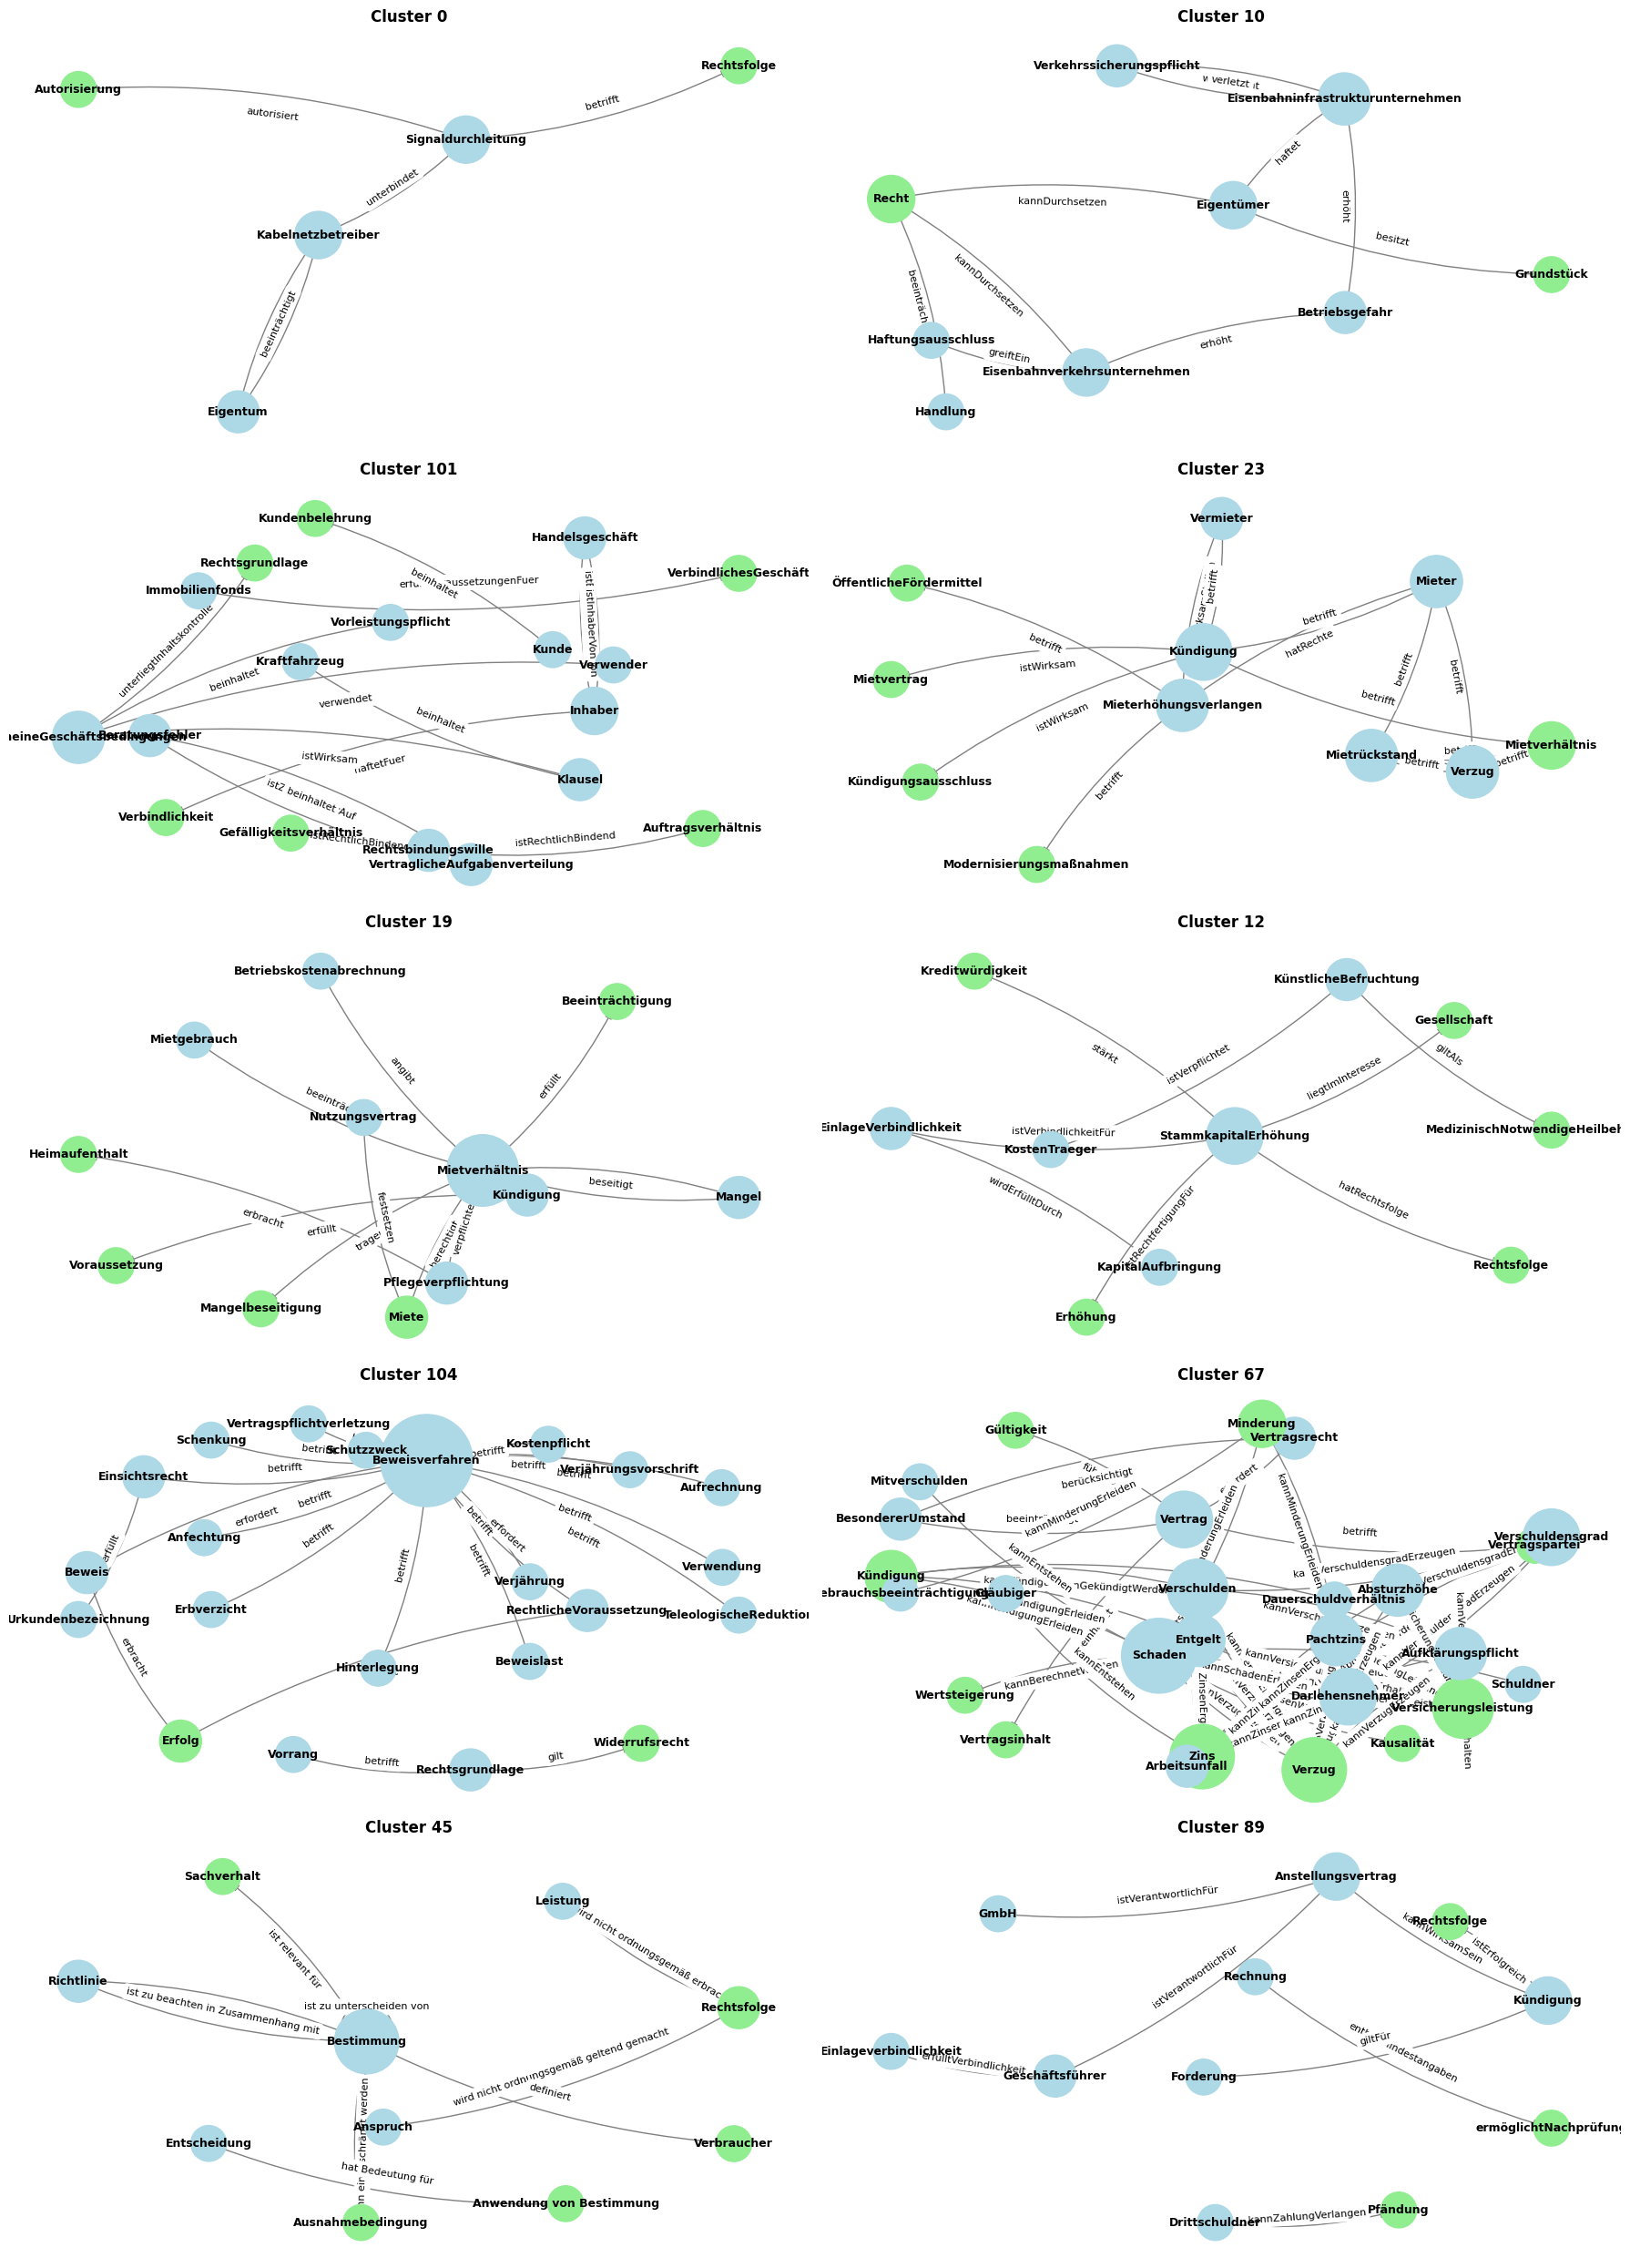

In [62]:
import json
import matplotlib.pyplot as plt
import networkx as nx

# === Load Refined Ontologies ===
with open("ontology_output/gcq_ontology_topdown_refined_source.json", "r", encoding="utf-8") as f:
    ontology_data = json.load(f)

# === Specify 10 Desired Clusters ===
selected_clusters = [
    "Cluster 0", "Cluster 10", "Cluster 101",
    "Cluster 23", "Cluster 19", "Cluster 12",
    "Cluster 104", "Cluster 67", "Cluster 45", "Cluster 89"
]

# === Plot Setup ===
num_clusters = len(selected_clusters)
cols = 2
rows = (num_clusters + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, cluster_id in enumerate(selected_clusters):
    data = ontology_data.get(cluster_id)
    ax = axes[i]

    if not data:
        print(f"⚠️ Cluster {cluster_id} not found in data.")
        ax.set_title(f"{cluster_id}: Not found")
        ax.axis("off")
        continue

    ontology = data.get("refined_ontology", {})
    relationships = ontology.get("relationships", [])

    if not relationships:
        ax.set_title(f"{cluster_id}: No relationships")
        ax.axis("off")
        continue

    G = nx.DiGraph()
    for subj, pred, obj in relationships:
        G.add_edge(subj, obj, label=pred)

    pos = nx.spring_layout(G, k=1.3, seed=42)
    degrees = dict(G.degree())

    node_colors = ["lightblue" if node in [r[0] for r in relationships] else "lightgreen" for node in G.nodes()]
    node_sizes = [500 + degrees[n] * 300 for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), font_size=8, ax=ax)

    # Just show the cluster ID
    ax.set_title(f"{cluster_id}", fontsize=12, fontweight="bold")
    ax.axis("off")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
